# Jitter mount pipeline (browse → tag → epochs → histograms)

End-to-end interactive workflow for the head-mount jitter comparison.

1. **Browse** the filesystem and multi-select block folders, tagging each `modular` / `rigid` / `mouse` / `turtle` → writes `configs/jitter_mount_blocks.yaml`.
2. **QC** the registry (report present? how many frames? pixel size known?).
3. **Calibrate** the missing `analysis/LR_pix_size.csv` files so displacement can be reported in µm.
4. **Pick epochs** of stable recording on each block's amplitude trace.
5. **Pool + plot** the modular-vs-rigid overlay plus gray single-mount histograms (modular, rigid, mouse, turtle), choosing which blocks take part.
6. **Finalize** into a dated folder with the PDFs plus a pickle that can redraw them.
7. **Working-run outputs** — scratch PDFs from section 5 (finalized copies live in the export folder).
8. **Joint 2×2 histogram** — rigid / modular lizard, mouse, turtle on one shared x-limit, with per-mount bin widths so integer-pixel quantization does not leave empty bars.
9. **Jitter summary CSV** — median and 95th-percentile displacement per mount type → `outputs/jitter_csv_values/jitter_values.csv`.
10. **Joint 2×2 in pixels** — same panels and ticked blocks, raw camera pixels, written to a separate folder so it does not overwrite the µm figure.

**Scope note.** Jitter *correction* itself (cross-correlation on the videos, `correct_jitter`) belongs to the preprocessing GUI. This pipeline reads the `analysis/jitter_report_dict.pkl` it already produced and quantifies the residual camera movement — it never recomputes from video.

Outputs land in `outputs/<run>/{figures,metadata}/`; empty `TAG` overwrites `jitter_latest`.

## 0. Setup

In [8]:
%matplotlib inline
from __future__ import annotations

import os
import sys
from pathlib import Path

REPO = Path.cwd()
if not (REPO / "src" / "eye_tracking_system_tools").is_dir():
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "src" / "eye_tracking_system_tools").is_dir():
            REPO = p
            break

sys.path.insert(0, str(REPO / "src"))
os.environ.setdefault("MPLCONFIGDIR", str(REPO / ".mplconfig"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(exist_ok=True)

from eye_tracking_system_tools.analysis.jitter_epochs import (
    export_unified_jitter,
    read_registry_blocks,
    run_plot_pooled,
    seed_middle_epochs,
)
from eye_tracking_system_tools.analysis.jitter_export import (
    bundle_samples_long,
    describe_bundle,
    finalize_jitter_export,
    load_jitter_bundle,
    plot_from_bundle,
)
from eye_tracking_system_tools.analysis.jitter_gui import (
    JitterBlockBrowser,
    JitterEpochPicker,
    JitterPoolSelector,
    PixelCalibrationPanel,
    registry_table,
)
from eye_tracking_system_tools.analysis.run_layout import resolve_run_dir

REGISTRY = REPO / "configs" / "jitter_mount_blocks.yaml"
OUT_ROOT = REPO / "outputs"
TAG = ""  # empty → jitter_latest (overwrite); e.g. "mount_v1" → jitter_mount_v1

RUN = resolve_run_dir(OUT_ROOT, TAG or None, prefix="jitter", default_name="jitter_latest")
print("REPO    :", REPO)
print("registry:", REGISTRY)
print("run     :", RUN.run_dir)
print("  figures :", RUN.figures_dir)
print("  metadata:", RUN.metadata_dir)

REPO    : /Users/nimi/Projects/PETS
registry: /Users/nimi/Projects/PETS/configs/jitter_mount_blocks.yaml
run     : /Users/nimi/Projects/PETS/outputs/jitter_latest
  figures : /Users/nimi/Projects/PETS/outputs/jitter_latest/figures
  metadata: /Users/nimi/Projects/PETS/outputs/jitter_latest/metadata


## 1. Pick block folders

* **Root** jumps to mounted experiment volumes / sample data; **Path** + **Go** accepts a typed path.
* The listing marks folders that already hold `analysis/jitter_report_dict.pkl` with **✓**.
* Ctrl/⌘-click or shift-click for multi-select, then **Add selected** with the chosen **Mount** type.
* **Scan & add below** walks the selected folders (or the current one) and stages every block with a report — handy for a whole animal or date.
* **Save registry** writes `configs/jitter_mount_blocks.yaml`.

Blocks without a jitter report are skipped: run the preprocessing GUI jitter step for those first.

In [9]:
browser = JitterBlockBrowser(REGISTRY, repo=REPO)
browser

In [10]:
# Saves whatever is staged above (same as the Save registry button).
browser.save()
specs = read_registry_blocks(REGISTRY)
print(f"{len(specs)} block(s) in {REGISTRY}")

49 block(s) in /Users/nimi/Projects/PETS/configs/jitter_mount_blocks.yaml


## 2. QC the registry

`calibrated` tells you whether the block carries `analysis/LR_pix_size.csv`; without it the displacements stay in camera pixels.

In [11]:
specs = read_registry_blocks(REGISTRY)
table = registry_table(specs, RUN.metadata_dir)
display(table)
print(table["mount_type"].value_counts().to_string())

uncalibrated = table.loc[table["calibrated"] != True, "block"].tolist()  # noqa: E712
print(
    f"\n{len(uncalibrated)} block(s) still need a pixel calibration: {uncalibrated}"
    if uncalibrated
    else "\nAll blocks have analysis/LR_pix_size.csv — displacements will be in µm."
)

,animal,block,mount_type,report,left_frames,right_frames,calibrated,L_um_per_px,R_um_per_px,n_epochs,block_path
0,PV_106,block_008,rigid,True,59073,59232,True,63.400,50.000,2,/Volumes/Data-1/Nimrod/experiments/PV_106/2025...
1,PV_106,block_009,rigid,True,58842,59026,True,63.200,50.000,6,/Volumes/Data-1/Nimrod/experiments/PV_106/2025...
2,PV_106,block_010,rigid,True,58277,58438,True,63.200,50.500,4,/Volumes/Data-1/Nimrod/experiments/PV_106/2025...
3,PV_106,block_011,rigid,True,133268,133280,True,59.000,47.000,0,/Volumes/Data-1/Nimrod/experiments/PV_106/2025...
4,PV_106,block_012,rigid,True,114913,115194,True,59.000,47.000,8,/Volumes/Data-1/Nimrod/experiments/PV_106/2025...
5,PV_106,block_013,rigid,True,58848,39298,True,41.033,35.733,4,/Volumes/Data-1/Nimrod/experiments/PV_106/2025...
6,PV_106,block_014,rigid,True,39117,38934,True,35.255,35.309,6,/Volumes/Data-1/Nimrod/experiments/PV_106/2025...
7,PV_106,block_015,rigid,True,19799,19700,True,41.155,41.408,4,/Volumes/Data-1/Nimrod/experiments/PV_106/2025...
8,PV_106,block_016,rigid,True,71016,70754,True,47.670,32.196,8,/Volumes/Data-1/Nimrod/experiments/PV_106/2025...
9,PV_126,block_006,rigid,True,79223,79216,True,28.637,27.270,0,/Volumes/Data-1/Nimrod/experiments/PV_126/2024...


mount_type
rigid      36
modular     8
mouse       4
turtle      1

All blocks have analysis/LR_pix_size.csv — displacements will be in µm.


## 3. Pixel-size calibration (px → µm)

The jitter report measures displacement in **camera pixels**, so every block needs its own scale factor before the groups can be compared: `analysis/LR_pix_size.csv` with `L_pix_size` / `R_pix_size` in **mm per pixel**. That is the same file (and the same ROI-diagonal logic) as `BlockSync.calibrate_pixel_size`, so calibrations made here are reused by the preprocessing pipeline and vice versa — but no BlockSync object is mounted.

* Rows marked **✗** need calibration; **Select uncalibrated** picks them all.
* **Calibrate selected** opens an OpenCV window per eye: drag a box whose **diagonal** spans the known distance on the landmark, then press **Enter** (Esc cancels). Set *Known dist [mm]* first — the lab default is 10 mm.
* The window opens on the machine running the kernel, so run this notebook locally (not on a remote server).
* If a block's raw mp4s are offline, enter **L/R µm/px** (the same numbers the list shows after refresh) and use **Manual entry**.


In [12]:
calib = PixelCalibrationPanel(specs, known_dist_mm=10.0)
calib

In [13]:
display(registry_table(specs, RUN.metadata_dir)[
    ["animal", "block", "mount_type", "calibrated", "L_um_per_px", "R_um_per_px"]
])
print(f"still uncalibrated: {[s.block_key for s in calib.missing]}")

,animal,block,mount_type,calibrated,L_um_per_px,R_um_per_px
0,PV_106,block_008,rigid,True,63.400,50.000
1,PV_106,block_009,rigid,True,63.200,50.000
2,PV_106,block_010,rigid,True,63.200,50.500
3,PV_106,block_011,rigid,True,59.000,47.000
4,PV_106,block_012,rigid,True,59.000,47.000
5,PV_106,block_013,rigid,True,41.033,35.733
6,PV_106,block_014,rigid,True,35.255,35.309
7,PV_106,block_015,rigid,True,41.155,41.408
8,PV_106,block_016,rigid,True,47.670,32.196
9,PV_126,block_006,rigid,True,28.637,27.270


still uncalibrated: []


## 4. Pick stable epochs

Only frames inside the epochs you select are pooled into the histograms — use it to exclude handling artifacts, lights-out stretches and other non-stationary periods.

The trace is drawn in µm for calibrated blocks and falls back to px otherwise (the status line says which). Epoch bounds are frame indices either way, so calibrating later does not invalidate them.

* **View** zooms the x-axis; the **Select** slider is constrained to the visible window, so zoom in for frame-level precision.
* **Add epoch** stores the current selection for the eye(s) chosen in **Eye**.
* **Save epochs** / **Save all blocks** write `metadata/jitter_epochs/<animal>_<block>_epochs.yaml`, which is re-loaded on the next run so you can refine later.

In [14]:
picker = JitterEpochPicker(specs, RUN.metadata_dir)
picker

In [15]:
picker.save_all()

# Non-interactive shortcut for a first pass (middle 50% of every trace):
# seed_middle_epochs(specs, RUN.metadata_dir, frac=0.5)

[PosixPath('/Users/nimi/Projects/PETS/outputs/jitter_latest/metadata/jitter_epochs/PV_106_block_008_epochs.yaml')]

## 5. Pool epochs → histograms

`modular` + `rigid` go into the Fig 1e–style **transparent overlay**, and each mount type (`modular`, `rigid`, `mouse`, `turtle`) also gets its own gray single-mount PDF when that pool has samples.

Amplitude is `top_correlation_dist` from the jitter report. With `UNITS="um"` each eye's trace is scaled by that block's `L_pix_size` / `R_pix_size`, so blocks with different camera-to-eye distances become comparable; the run fails loudly and names the offenders if any block is still uncalibrated. `UNITS="px"` skips the scaling and reports raw pixels.

Tick the blocks to pool — each row carries that block's **mean**, **95th percentile** and **raw maximum** displacement plus its sample count, so a block whose typical jitter is fine but has a few artifact spikes is distinguishable from one that is bad throughout. Blocks without saved epochs are greyed out. **Sort** by any of those statistics to bring the worst offenders to the top, then **Pool & plot selected**; the chosen blocks and their full stats are recorded under `blocks_used` in `jitter_pool_summary.yaml`. Samples are cached on load, so re-plotting a different subset is instant — hit **Reload** after saving new epochs above.


In [16]:
UNITS = "um"  # "px" to skip the pixel-size scaling
N_BINS = 15

pool = JitterPoolSelector(specs, RUN.figures_dir, RUN.metadata_dir, units=UNITS, n_bins=N_BINS)
pool

In [17]:
print("pooled blocks:", pool.selected)
written = pool.written

# Headless equivalent — same call with an explicit block list:
# written = run_plot_pooled(
#     specs, RUN.figures_dir, RUN.metadata_dir,
#     units=UNITS, n_bins=N_BINS, show=True,
#     include=["PV_143_block_001", "PV_24_block_012"],  # omit to pool everything
# )

pooled blocks: ['PV_106_block_008', 'PV_106_block_009', 'PV_106_block_010', 'PV_106_block_012', 'PV_106_block_013', 'PV_106_block_014', 'PV_106_block_015', 'PV_106_block_016', 'PV_126_block_007', 'PV_126_block_008', 'PV_126_block_009', 'PV_126_block_011', 'PV_126_block_012', 'PV_126_block_013', 'PV_126_block_015', 'PV_143_block_001', 'PV_143_block_002', 'PV_143_block_003', 'PV_143_block_004', 'PV_24_block_012', 'PV_24_block_013', 'PV_24_block_034', 'PV_62_block_024', 'PV_62_block_025', 'PV_62_block_026', 'PV_62_block_027', 'M_002_block_012', 'M_002_block_013', 'M_002_block_014', 'M_002_block_015', 'PV_228_block_005', 'PV_228_block_013', 'PV_228_block_016', 'PV_228_block_017', 'T_18_block_001']


## 6. Finalize — dated export of figures + data

Once the checklist above is filtered to your satisfaction, run this to freeze the result. It creates

```
outputs/jitter_comparison_figures_<tag>_<YYYYMMDD>_<HH>_<MM>/
    jitter_modular_vs_rigid.pdf
    jitter_modular.pdf / jitter_rigid.pdf / jitter_mouse.pdf / jitter_turtle.pdf
        (gray single-mount hists when that pool has samples)
    jitter_comparison_data.pickle     # everything needed to redraw or re-edit
    epochs_table.csv                  # same inventory without the arrays
    manifest.yaml                     # provenance: blocks, stats, settings
```

The pickle's `epochs` table has **one row per pooled epoch**, carrying where it came from (`animal`, `date`, `block`, `mount_type`, `eye`, `epoch_index`), the **frame span** it was cut from (`start_frame` / `end_frame`), the µm/px factor applied (`scale_um_per_px`, so you can go back to pixels), and two arrays: `frames` and `displacement` — every plotted value with the video frame index behind it.

Nothing is ever overwritten: a second export in the same minute gets a `_2` suffix.


[skip] no epochs yet for PV_106_block_011: /Users/nimi/Projects/PETS/outputs/jitter_latest/metadata/jitter_epochs/PV_106_block_011_epochs.yaml
[skip] no epochs yet for PV_126_block_006: /Users/nimi/Projects/PETS/outputs/jitter_latest/metadata/jitter_epochs/PV_126_block_006_epochs.yaml
[skip] no epochs yet for PV_126_block_010: /Users/nimi/Projects/PETS/outputs/jitter_latest/metadata/jitter_epochs/PV_126_block_010_epochs.yaml
[skip] no epochs yet for PV_126_block_014: /Users/nimi/Projects/PETS/outputs/jitter_latest/metadata/jitter_epochs/PV_126_block_014_epochs.yaml
[skip] no epochs yet for PV_62_block_023: /Users/nimi/Projects/PETS/outputs/jitter_latest/metadata/jitter_epochs/PV_62_block_023_epochs.yaml
[skip] no epochs yet for PV_228_block_001: /Users/nimi/Projects/PETS/outputs/jitter_latest/metadata/jitter_epochs/PV_228_block_001_epochs.yaml
[skip] no epochs yet for PV_228_block_002: /Users/nimi/Projects/PETS/outputs/jitter_latest/metadata/jitter_epochs/PV_228_block_002_epochs.yaml
[

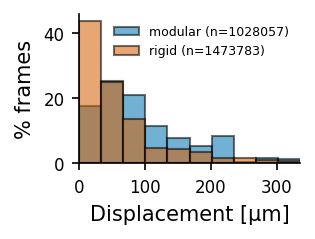

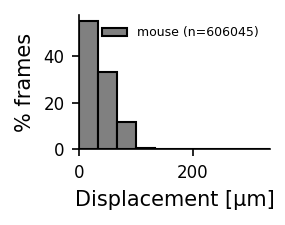

export: /Users/nimi/Projects/PETS/outputs/jitter_comparison_figures_mount_v1_20260801_21_20
  modular_vs_rigid: jitter_modular_vs_rigid.pdf
  mouse: jitter_mouse.pdf
  data: jitter_comparison_data.pickle


,animal,date,block,mount_type,eye,start_frame,end_frame,n_samples,max
0,PV_106,2025_08_06,block_008,rigid,left_eye,1037,4990,3953,2516.908135
1,PV_106,2025_08_06,block_008,rigid,right_eye,1037,4990,3953,2000.000000
2,PV_106,2025_08_06,block_009,rigid,left_eye,0,10450,10450,2783.671245
3,PV_106,2025_08_06,block_009,rigid,left_eye,15402,43522,28120,2783.671245
4,PV_106,2025_08_06,block_009,rigid,left_eye,45293,55328,10035,2783.671245
...,...,...,...,...,...,...,...,...,...
135,PV_228,2026_06_15,block_013,rigid,right_eye,28591,39269,10678,2611.658930
136,PV_228,2026_06_15,block_016,rigid,left_eye,10044,51329,41285,3240.208602
137,PV_228,2026_06_15,block_016,rigid,right_eye,10044,51467,41423,2222.982054
138,PV_228,2026_06_17,block_017,rigid,left_eye,250,1842,1592,183.836437


In [14]:
EXPORT_TAG = "mount_v1"  # goes into the folder name; "" for a bare timestamp
EXPORT_NOTES = "Includes both rigid and modular lizard blocks, plus modular mouse blocks. Manually picked stable epochs."  # free text stored in the manifest, e.g. why blocks were dropped
N_BINS = 10
export = finalize_jitter_export(
    specs,
    RUN.metadata_dir,
    OUT_ROOT,
    tag=EXPORT_TAG,
    units=UNITS,
    n_bins=N_BINS,
    include=pool.selected,  # the ticked blocks; None = every block with epochs
    notes=EXPORT_NOTES,
    registry=REGISTRY,
    show=True,
)

display(export.epochs[
    ["animal", "date", "block", "mount_type", "eye", "start_frame", "end_frame", "n_samples", "max"]
])

### Re-creating the plots from the export

The bundle is self-contained — the cell below works in a fresh kernel, months later, with only the export folder. Point `BUNDLE` at any `jitter_comparison_figures_*` folder (or its `.pickle`) to redraw exactly what was published, restyle it (`n_bins`, `xmax`), or re-plot a filtered subset without recomputing anything.

In [5]:
BUNDLE = export.export_dir  # or a path to any earlier jitter_comparison_figures_* folder

bundle = load_jitter_bundle(BUNDLE)
display(describe_bundle(bundle))

# 1. Redraw as published (display only — pass out_dir=... to write PDFs)
plot_from_bundle(bundle)

# 2. Restyle, or re-plot a subset, without touching the pooled data:
# plot_from_bundle(bundle, n_bins=25, xmax=400)
# plot_from_bundle(bundle, include=["PV_143_block_001"])
# keep = bundle["epochs"].query("max < 1000 and eye == 'left_eye'")
# plot_from_bundle(bundle, epochs=keep, out_dir=BUNDLE, suffix="_left_only")

# 3. The displacement values themselves, one row per sample, mapped back to source:
samples = bundle_samples_long(bundle)
print(f"\n{len(samples):,} samples in {samples.attrs['units']}")
display(samples.head())
display(samples.groupby("mount_type")["displacement"].describe())

NameError: name 'export' is not defined

## 7. Working-run outputs

The scratch figures from section 5 (the finalized copies live in the export folder above).

In [20]:
import yaml
from IPython.display import FileLink, Markdown, display

summary_path = RUN.metadata_dir / "jitter_pool_summary.yaml"
if summary_path.exists():
    print(yaml.safe_dump(yaml.safe_load(summary_path.read_text()), sort_keys=False))

# FileLink resolves against the kernel cwd (development/), not REPO.
CWD = Path.cwd().resolve()
for p in sorted(RUN.figures_dir.rglob("*.pdf")):
    rel = os.path.relpath(p.resolve(), CWD)
    display(FileLink(rel) if os.path.exists(rel) else Markdown(f"[{p.name}]({p.resolve().as_uri()})"))

created_utc: '2026-08-01T16:49:50.515913+00:00'
units: um
note: Amplitude from jitter_report_dict top_correlation_dist, scaled per eye by analysis/LR_pix_size.csv
  (mm/px).
groups:
  modular:
    n_samples: 863211
    mean: 88.59560447760968
    median: 88.0024641034928
    p95: 211.3772852696525
    max: 3527.9115876312408
  rigid:
    n_samples: 652116
    mean: 70.85319036225422
    median: 42.4
    p95: 261.52730044138656
    max: 4749.849745558871
  mouse:
    n_samples: 606045
    mean: 37.89728437166942
    median: 27.539746159067423
    p95: 89.91693264478074
    max: 1854.386333390279
blocks_used:
- block_key: PV_106_block_014
  animal: PV_106
  block: block_014
  mount_type: rigid
  units: um
  n_samples: 33114
  max: 2650.765039070336
  p95: 211.8541580104128
  median: 0.0
  mean: 45.22880086280633
- block_key: PV_106_block_015
  animal: PV_106
  block: block_015
  mount_type: rigid
  units: um
  n_samples: 16104
  max: 3398.480911790071
  p95: 130.94345498083553
  median: 

/Users/nimi/Projects/PETS/outputs/jitter_latest/figures/jitter_modular_vs_rigid.pdf

/Users/nimi/Projects/PETS/outputs/jitter_latest/figures/jitter_mouse.pdf

## 8. Joint four-panel histogram

`export_unified_jitter` draws the publication 2×2 (rigid lizard, modular lizard, modular mouse, modular turtle). All panels share one x-limit — the 99.5th percentile of the jitteriest mount — so amplitudes stay comparable.

Bar **width** is per panel. `top_correlation_dist` is an integer-pixel Euclidean length, then scaled by µm/px, so each mount is a discrete lattice. A single `n_bins` across panels puts edges between lattice rings (empty bars that look like missing data). Each panel's width is `PIXEL_BIN_K` × the coarsest 1-pixel step among that mount's ticked blocks. `PIXEL_BIN_K` may be one number or a dict (`lizard` covers rigid + modular), e.g. `{"turtle": 1.0, "lizard": 1.0, "mouse": 2}`.

Uses the same ticked blocks as section 5 (`pool.selected`).

unified jitter bin widths (plot units): modular=45, rigid=50.5, mouse=51.3, turtle=40


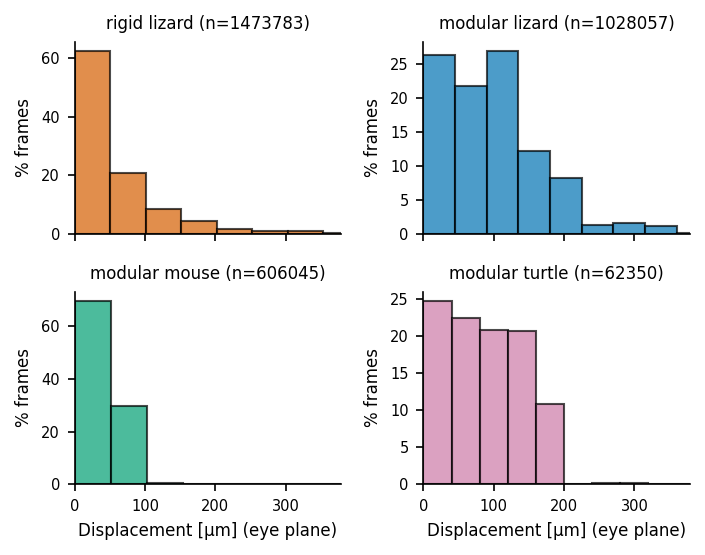

unified: /Users/nimi/Projects/PETS/outputs/jitter_latest/unified jitter quantification across animals/plots/unified_jitter_quantification.pdf
summary: /Users/nimi/Projects/PETS/outputs/jitter_latest/unified jitter quantification across animals/metadata/unified_jitter_summary.yaml


In [18]:
PIXEL_BIN_K = {"turtle": 1.0, "lizard": 1.0, "mouse": 4}  # or a scalar, e.g. 1.0

unified = export_unified_jitter(
    specs,
    RUN.figures_dir,
    RUN.metadata_dir,
    units=UNITS,
    pixel_bin_k=PIXEL_BIN_K,
    show=True,
    include=pool.selected,
    block_samples=pool.block_samples,
)
print("unified:", unified["unified"])
print("summary:", unified["summary"])

## 9. Median and 95th-percentile displacement

Same pooled epoch samples as the joint plot (section 5 ticks). Writes `outputs/jitter_csv_values/jitter_values.csv`.

In [ ]:
import numpy as np
import pandas as pd
from eye_tracking_system_tools.analysis.jitter_epochs import (
    UNIFIED_JITTER_PANELS,
    pool_block_samples,
)

csv_path = REPO / "outputs" / "jitter_csv_values" / "jitter_values.csv"
csv_path.parent.mkdir(parents=True, exist_ok=True)

if "pool" in dir() and getattr(pool, "block_samples", None):
    pools = pool_block_samples(pool.block_samples, include=pool.selected)
    units = getattr(pool, "units", "um")
else:
    import pickle

    pkl = (
        RUN.run_dir
        / "unified jitter quantification across animals"
        / "metadata"
        / "unified_jitter.pkl"
    )
    with open(pkl, "rb") as f:
        payload = pickle.load(f)
    pools = payload["pools"]
    units = payload.get("units", "um")

rows = []
for mount, label, _color in UNIFIED_JITTER_PANELS:
    arr = np.asarray(pools.get(mount, []), dtype=float)
    arr = arr[np.isfinite(arr)]
    rows.append(
        {
            "mount_type": mount,
            "label": label,
            "n_samples": int(arr.size),
            "median_um": float(np.median(arr)) if arr.size else np.nan,
            "p95_um": float(np.percentile(arr, 95)) if arr.size else np.nan,
            "units": units,
        }
    )
jitter_values = pd.DataFrame(rows)
jitter_values.to_csv(csv_path, index=False)
display(jitter_values)
print("wrote", csv_path)

## 10. Joint four-panel histogram in pixels

Same ticked blocks as section 8, but `top_correlation_dist` is left in camera pixels (no `LR_pix_size` scaling). This is the native unit of the correlation-peak estimator — an integer Euclidean lattice (`0, 1, √2, 2, …`) that is the same for every camera.

The µm figure is **not** overwritten: `units="px"` writes `unified jitter quantification across animals px/`. Bar width is one camera pixel (`PIXEL_BIN_K_PX = 1`).

µm is the right unit for comparing physical mount motion across species (different magnification). Pixels are the right unit for asking how many camera pixels the residual shift is. There is no unique µm → Kerr-degree conversion; see the notes below this cell.

In [ ]:
from eye_tracking_system_tools.analysis.jitter_epochs import collect_block_samples

PIXEL_BIN_K_PX = 1.0  # native 1-pixel Euclidean lattice for every mount

if "pool" in dir() and getattr(pool, "selected", None):
    include_px = pool.selected
else:
    import yaml

    summary = yaml.safe_load((RUN.metadata_dir / "jitter_pool_summary.yaml").read_text())
    include_px = [b["block_key"] for b in summary.get("blocks_used") or []]

px_samples = collect_block_samples(specs, RUN.metadata_dir, units="px")
unified_px = export_unified_jitter(
    specs,
    RUN.figures_dir,
    RUN.metadata_dir,
    units="px",
    pixel_bin_k=PIXEL_BIN_K_PX,
    show=True,
    include=include_px,
    block_samples=px_samples,
)
print("unified px:", unified_px["unified"])
print("summary   :", unified_px["summary"])

## Notes

| Step | Where it lives |
|------|----------------|
| Block registry | `configs/jitter_mount_blocks.yaml` |
| Pixel calibration | `<block>/analysis/LR_pix_size.csv` (+ `.meta.yaml` provenance) |
| Epoch selections | `outputs/<run>/metadata/jitter_epochs/*.yaml` |
| Pooled stats | `outputs/<run>/metadata/jitter_pool_summary.yaml` |
| Working figures | `outputs/<run>/figures/jitter_*.pdf`, `unified jitter quantification across animals/` (µm), and `unified jitter quantification across animals px/` |
| Jitter summary CSV | `outputs/jitter_csv_values/jitter_values.csv` |
| Finalized export | `outputs/jitter_comparison_figures_<tag>_<date>_<hh>_<mm>/` |
| Widgets | `analysis/jitter_gui.py` |
| Headless logic | `analysis/jitter_epochs.py`, `analysis/pixel_calibration.py`, `analysis/jitter_export.py` |

Equivalent CLI (epoch picking there uses a matplotlib SpanSelector window instead of the widgets):

```bash
PYTHONPATH=src python -m eye_tracking_system_tools.analysis.jitter_epochs \
  --registry configs/jitter_mount_blocks.yaml \
  --out-root outputs --tag "" --pick --plot

# first pass without picking, staying in pixels
PYTHONPATH=src python -m eye_tracking_system_tools.analysis.jitter_epochs \
  --registry configs/jitter_mount_blocks.yaml \
  --out-root outputs --tag "" --seed-middle-frac 0.5 --plot --units px

# pool a subset: --select prints the same checklist as text, --include names blocks
PYTHONPATH=src python -m eye_tracking_system_tools.analysis.jitter_epochs --plot --select
PYTHONPATH=src python -m eye_tracking_system_tools.analysis.jitter_epochs \
  --plot --include PV_143_block_001 PV_24_block_012
```

`LR_pix_size.csv` keeps exactly the columns `BlockSync.calibrate_pixel_size` writes and reads, so a block calibrated in either place needs no second pass. To script it outside the notebook:

```python
from eye_tracking_system_tools.analysis.pixel_calibration import (
    calibrate_block,
    manual_calibration_um_per_px,
    read_pixel_size,
)

calibrate_block("/path/to/block_012", known_dist_mm=10.0)   # opens the ROI windows
manual_calibration_um_per_px("/path/to/block_012", left_um_per_px=12.5, right_um_per_px=13.0)
read_pixel_size("/path/to/block_012").l_um_per_px
```

Reopening a finalized export elsewhere (no repo state needed beyond the package):

```python
from eye_tracking_system_tools.analysis.jitter_export import load_jitter_bundle, plot_from_bundle

bundle = load_jitter_bundle("outputs/jitter_comparison_figures_mount_v1_20260801_20_45")
bundle["epochs"]          # per-epoch table + frames/displacement arrays
plot_from_bundle(bundle)  # redraw; add out_dir=... to write PDFs
```
